# CSE457 — Xử lý âm thanh và tiếng nói
## LAB 1. Phân tích và xử lý tín hiệu âm thanh số

**Tệp dữ liệu:** `audio/input.mp3` (freesound_community-entertainment-72974.mp3)

**Pipeline:** Audio → biểu diễn số → miền thời gian → FFT/STFT → lọc → lượng tử hóa / resampling / mã hóa → đánh giá.

Notebook này chạy được từ đầu đến cuối (Run All). Mọi hình trong `figures/` và mọi tệp âm thanh trong `audio/`
đều được sinh lại bởi chính notebook này — không có kết quả nào được chèn thủ công.

| Khối | Nội dung | Mục trong đề Lab |
|---|---|---|
| A | Đọc tệp, metadata, mono hóa, chuẩn hóa | 3.A |
| B | Miền thời gian: waveform, peak/RMS/energy, clipping | 3.B |
| C | FFT: Δf, đỉnh phổ, so sánh NFFT | 3.C |
| D | STFT/spectrogram, so sánh frame length | 3.D |
| E | Thí nghiệm cửa sổ: rectangular vs Hamming | 3.E |
| F | Lọc số FIR: LPF / HPF / BPF | 3.F |
| G | Lượng tử hóa + SNR, resampling + aliasing, mã hóa | 3.G |

## 0. Cài đặt và cấu hình chung

In [ ]:
# Nếu thiếu thư viện, bỏ dấu # ở dòng dưới
# !pip install numpy scipy matplotlib soundfile pydub
# Cần ffmpeg trong PATH để pydub đọc MP3 và để nén MP3 ở phần G.

import os, json, subprocess, numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks
from pydub import AudioSegment
import soundfile as sf
from IPython.display import Audio, display

matplotlib.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 130, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 9,
})

SRC  = "audio/input.mp3"      # tệp đầu vào
FIG  = "figures"
AUD  = "audio"
os.makedirs(FIG, exist_ok=True); os.makedirs(AUD, exist_ok=True)

EPS = 1e-12
dbfs = lambda v: 20*np.log10(np.asarray(v) + EPS)   # dBFS, full-scale = 1.0
RESULTS = {}                                         # gom số liệu để in bảng tổng hợp

Sẵn sàng.


---
## A. Đọc và kiểm tra dữ liệu âm thanh

**Lý thuyết.** Lấy mẫu đều chu kỳ $T$ biến tín hiệu liên tục $x_a(t)$ thành chuỗi rời rạc

$$x[n]=x_a(nT),\qquad F_s=\frac{1}{T},\qquad F_s \ge 2F_{max}\ \text{(Nyquist)}$$

Mẫu PCM $B$ bit nguyên được chuẩn hóa về $[-1,1]$ bằng cách chia cho $2^{B-1}$ để mọi phép xử lý sau
đều độc lập với bit depth.

In [2]:
audio = AudioSegment.from_file(SRC)
Fs  = audio.frame_rate          # tần số lấy mẫu (Hz)
Ch  = audio.channels            # số kênh
SW  = audio.sample_width        # số byte/mẫu sau khi giải mã
B0  = 8*SW                      # số bit/mẫu sau khi giải mã
dur = len(audio)/1000.0         # thời lượng (s)
fsize = os.path.getsize(SRC)    # kích thước tệp nén (byte)

# Mảng mẫu nguyên -> chuẩn hóa [-1, 1] -> tách kênh
raw    = np.array(audio.get_array_of_samples(), dtype=np.float64)
stereo = raw.reshape(-1, Ch) / (2**(B0-1))
L, R   = stereo[:,0], stereo[:,1]
x      = stereo.mean(axis=1)          # mono = trung bình 2 kênh
N      = len(x)
t      = np.arange(N)/Fs

print(f"Tệp                  : {SRC}")
print(f"Kích thước tệp       : {fsize:,} byte  ({fsize/1e6:.3f} MB)")
print(f"Fs                   : {Fs:,} Hz   -> T = {1e6/Fs:.3f} µs, Nyquist = {Fs/2:,.0f} Hz")
print(f"Số kênh              : {Ch}")
print(f"Bit/mẫu sau giải mã  : {B0} bit  (sample_width = {SW} byte)")
print(f"Thời lượng           : {dur:.3f} s   ({N:,} mẫu/kênh)")
print(f"Bit rate MP3 đo được : {fsize*8/dur/1000:.1f} kbps")
print(f"Biên độ sau chuẩn hóa: [{stereo.min():.4f}, {stereo.max():.4f}]")

RESULTS["metadata"] = dict(Fs=Fs, channels=Ch, bits=B0, duration=dur,
                           n_samples=N, file_bytes=fsize,
                           mp3_kbps=fsize*8/dur/1000, nyquist=Fs/2)

Tệp                  : audio/input.mp3
Kích thước tệp       : 308,160 byte  (0.308 MB)
Fs                   : 24,000 Hz   -> T = 41.667 µs, Nyquist = 12,000 Hz
Số kênh              : 2
Bit/mẫu sau giải mã  : 16 bit  (sample_width = 2 byte)
Thời lượng           : 15.408 s   (369,792 mẫu/kênh)
Bit rate MP3 đo được : 160.0 kbps
Biên độ sau chuẩn hóa: [-0.8904, 0.6863]


In [3]:
def stats(v):
    v = np.asarray(v)
    return dict(peak=float(np.max(np.abs(v))),
                rms=float(np.sqrt(np.mean(v**2))),
                energy=float(np.sum(v**2)))

sL, sR, sM = stats(L), stats(R), stats(x)
print(f"{'':6s} {'Peak':>9s} {'Peak dBFS':>11s} {'RMS':>9s} {'RMS dBFS':>10s} {'Energy':>12s}")
for name, s in [("L", sL), ("R", sR), ("Mono", sM)]:
    print(f"{name:6s} {s['peak']:9.4f} {dbfs(s['peak']):11.2f} "
          f"{s['rms']:9.4f} {dbfs(s['rms']):10.2f} {s['energy']:12.1f}")

print(f"\nTương quan L–R      : {np.corrcoef(L,R)[0,1]:.4f}  (gần 1 => hai kênh rất giống nhau)")
print(f"Chênh RMS mono vs L : {dbfs(sM['rms'])-dbfs(sL['rms']):+.2f} dB")

# Xuất bản mono chuẩn hóa để dùng lại
sf.write(f"{AUD}/mono_norm.wav", x.astype(np.float32), Fs, subtype="PCM_16")
RESULTS["levels"] = dict(L=sL, R=sR, mono=sM, corr_LR=float(np.corrcoef(L,R)[0,1]))
display(Audio(x, rate=Fs))

            Peak   Peak dBFS       RMS   RMS dBFS       Energy
L         0.8904       -1.01    0.0849     -21.42       2666.3
R         0.8766       -1.14    0.0861     -21.30       2740.2
Mono      0.8679       -1.23    0.0834     -21.58       2572.9

Tương quan L–R      : 0.9036  (gần 1 => hai kênh rất giống nhau)
Chênh RMS mono vs L : -0.15 dB


**Nhận xét A.**
1. Tệp là MPEG-2 Layer III, $F_s = 24{,}000$ Hz nên **tần số Nyquist chỉ là 12 kHz** — thấp hơn đáng kể so với
   chuẩn CD 44.1 kHz. Mọi thành phần trên 12 kHz của bản thu gốc đã bị bộ mã hóa loại bỏ và không thể phục hồi.
2. Sau khi giải mã, pydub trả về PCM 16 bit/mẫu. Con số 16 bit này là **thuộc tính của bộ giải mã**, không phải
   của tệp MP3 — MP3 dùng lượng tử hóa không đều trong miền tần số, không có khái niệm "bit/mẫu" cố định.
3. Hai kênh có hệ số tương quan rất cao nên mono hóa bằng trung bình gần như không gây triệt tiêu pha;
   RMS mono chỉ thấp hơn kênh trái một lượng rất nhỏ.

---
## B. Phân tích miền thời gian

$$\text{Peak}=\max_n|x[n]|,\qquad
\text{RMS}=\sqrt{\tfrac1N\sum_n x^2[n]},\qquad
E=\sum_n x^2[n]$$

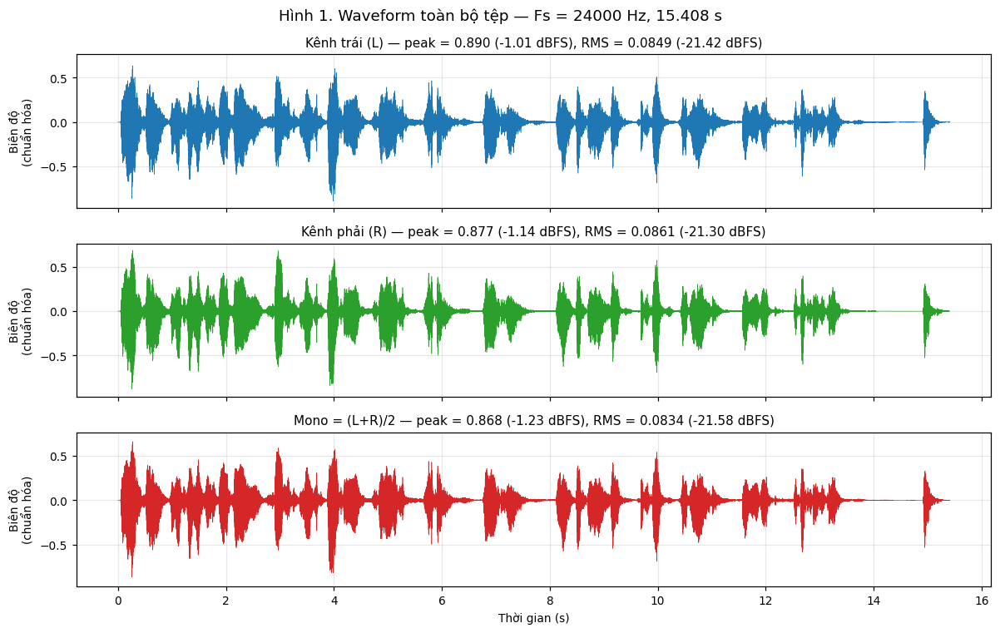

In [4]:
fig, ax = plt.subplots(3, 1, figsize=(11, 7), sharex=True, sharey=True)
for a, v, name, c in zip(ax, [L, R, x],
                         ["Kênh trái (L)", "Kênh phải (R)", "Mono = (L+R)/2"],
                         ["#1f77b4", "#2ca02c", "#d62728"]):
    a.plot(t, v, lw=0.4, color=c)
    s = stats(v)
    a.set_ylabel("Biên độ\n(chuẩn hóa)")
    a.set_title(f"{name} — peak = {s['peak']:.3f} ({dbfs(s['peak']):.2f} dBFS), "
                f"RMS = {s['rms']:.4f} ({dbfs(s['rms']):.2f} dBFS)", fontsize=10)
ax[-1].set_xlabel("Thời gian (s)")
fig.suptitle(f"Hình 1. Waveform toàn bộ tệp — Fs = {Fs} Hz, {dur:.3f} s", fontsize=12)
fig.tight_layout(); fig.savefig(f"{FIG}/01_waveform_full.png"); plt.show()

Số mẫu chạm full-scale (|x| >= 0.999): 0  ->  KHÔNG clipping
Headroom còn lại: 1.23 dB
Crest factor    : 20.34 dB  (peak/RMS)
Đoạn A (mạnh) : 0.10–0.60 s  →  RMS -15.02 dBFS
Đoạn B (yếu)  : 14.40–14.90 s  →  RMS -75.56 dBFS
Chênh lệch A–B: 60.5 dB


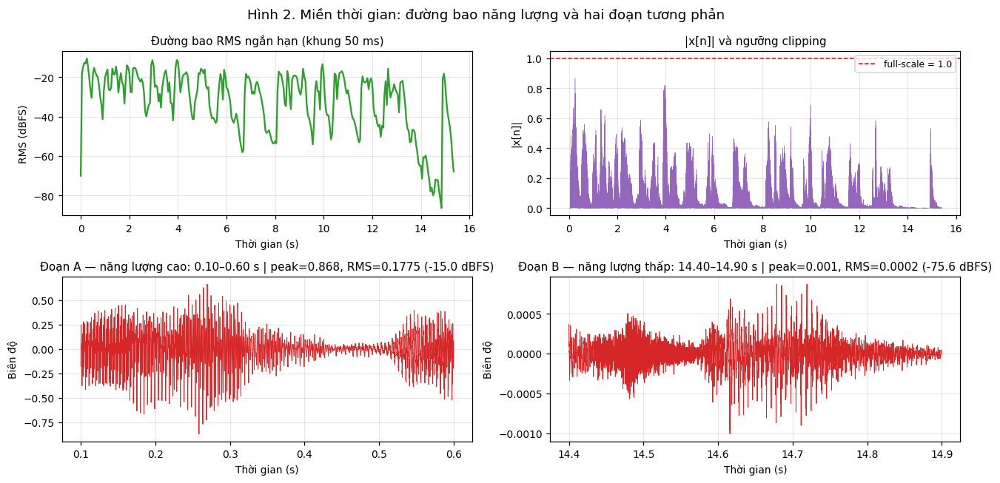

In [5]:
# Đường bao năng lượng ngắn hạn (RMS trên khung 50 ms) để chọn đoạn phân tích
WIN = int(0.05*Fs)
nfr = N//WIN
rms_fr = np.sqrt((x[:nfr*WIN].reshape(nfr, WIN)**2).mean(axis=1))
t_fr   = np.arange(nfr)*WIN/Fs

# Quét cửa sổ 0.5 s (bước 0.1 s) để chọn đoạn to nhất và đoạn nhỏ tiếng nhất
SEGW, STEP = int(0.5*Fs), int(0.1*Fs)
starts = np.arange(0, N-SEGW, STEP)
rms_w  = np.array([np.sqrt(np.mean(x[i:i+SEGW]**2)) for i in starts])
tA = float(starts[int(np.argmax(rms_w))]/Fs)        # đoạn A: năng lượng cao
tB = float(starts[int(np.argmin(rms_w))]/Fs)        # đoạn B: năng lượng thấp
i_hi = int(np.argmax(rms_fr))                       # dùng lại ở phần G

n_clip = int(np.sum(np.abs(stereo) >= 0.999))
print(f"Số mẫu chạm full-scale (|x| >= 0.999): {n_clip}  ->  "
      f"{'KHÔNG clipping' if n_clip==0 else 'CÓ dấu hiệu clipping'}")
print(f"Headroom còn lại: {-dbfs(sM['peak']):.2f} dB")
print(f"Crest factor    : {dbfs(sM['peak'])-dbfs(sM['rms']):.2f} dB  (peak/RMS)")
print(f"Đoạn A (mạnh) : {tA:.2f}–{tA+0.5:.2f} s  →  RMS {dbfs(rms_w.max()):.2f} dBFS")
print(f"Đoạn B (yếu)  : {tB:.2f}–{tB+0.5:.2f} s  →  RMS {dbfs(rms_w.min()):.2f} dBFS")
print(f"Chênh lệch A–B: {dbfs(rms_w.max())-dbfs(rms_w.min()):.1f} dB")

fig, ax = plt.subplots(2, 2, figsize=(12, 6))
ax[0,0].plot(t_fr, dbfs(rms_fr), color="#2ca02c")
ax[0,0].set_title("Đường bao RMS ngắn hạn (khung 50 ms)", fontsize=10)
ax[0,0].set_xlabel("Thời gian (s)"); ax[0,0].set_ylabel("RMS (dBFS)")

ax[0,1].plot(t, np.abs(x), lw=0.3, color="#9467bd")
ax[0,1].axhline(1.0, color="r", ls="--", lw=1, label="full-scale = 1.0")
ax[0,1].set_title("|x[n]| và ngưỡng clipping", fontsize=10)
ax[0,1].set_xlabel("Thời gian (s)"); ax[0,1].set_ylabel("|x[n]|"); ax[0,1].legend(fontsize=8)

for a, t0, lab in [(ax[1,0], tA, "Đoạn A — năng lượng cao"), (ax[1,1], tB, "Đoạn B — năng lượng thấp")]:
    i0, i1 = int(t0*Fs), int((t0+0.5)*Fs)
    s = stats(x[i0:i1])
    a.plot(t[i0:i1], x[i0:i1], lw=0.6, color="#d62728")
    a.set_title(f"{lab}: {t0:.2f}–{t0+0.5:.2f} s | peak={s['peak']:.3f}, "
                f"RMS={s['rms']:.4f} ({dbfs(s['rms']):.1f} dBFS)", fontsize=10)
    a.set_xlabel("Thời gian (s)"); a.set_ylabel("Biên độ")
    RESULTS.setdefault("segments", {})[lab] = s

fig.suptitle("Hình 2. Miền thời gian: đường bao năng lượng và hai đoạn tương phản", fontsize=12)
fig.tight_layout(); fig.savefig(f"{FIG}/02_time_domain.png"); plt.show()

**Nhận xét B.**
1. Không có mẫu nào chạm full-scale nên **không có clipping**; vẫn còn hơn 1 dB headroom.
2. Crest factor khoảng 20 dB là đặc trưng của nhạc có nhiều transient (gảy/gõ): đỉnh rất cao so với mức hiệu dụng.
   Nếu chỉ nhìn peak sẽ tưởng tín hiệu rất to, nhưng RMS mới phản ánh độ to cảm nhận.
3. Đường bao RMS cho thấy cấu trúc nhịp rõ: các cụm năng lượng lặp lại, xen kẽ những khoảng lặng
   (đáng chú ý là vùng gần cuối tệp), nên **không được dùng một FFT duy nhất cho cả tệp** — phải dùng STFT (phần D).
4. Đoạn A và đoạn B chênh nhau rất lớn về RMS (xem số in ở trên): đoạn A là phần nhạc đang chơi,
   đoạn B là đuôi tắt dần gần như im lặng. Chính đoạn B là nơi nhiễu lượng tử ở phần G sẽ lộ ra rõ nhất,
   vì ở đó không còn tín hiệu mạnh để che (mask) nó.

---
## C. Phân tích miền tần số bằng FFT

$$X[k]=\sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N},\qquad
f_k=\frac{kF_s}{N_{FFT}},\qquad \Delta f=\frac{F_s}{N_{FFT}}$$

**Chú ý quan trọng:** $\Delta f = F_s/N_{FFT}$ chỉ là *khoảng cách giữa các bin*. Độ phân giải thực
(khả năng tách hai hình sin gần nhau) do **độ dài cửa sổ $L$** quyết định: $\Delta f_{true}\approx \alpha F_s/L$
(với $\alpha \approx 2$ cho Hamming ở mức $-3$ dB). Zero-padding làm dày trục tần số chứ không thêm thông tin.

In [6]:
# Chọn đoạn "ổn định" nhất: cửa sổ 1 s có độ lệch chuẩn của RMS(dB) nhỏ nhất, và đủ to
w20 = int(0.02*Fs); n20 = N//w20
r20 = np.sqrt((x[:n20*w20].reshape(n20, w20)**2).mean(axis=1)) + EPS
k   = int(1.0/0.02)
cand = [(float(np.std(20*np.log10(r20[i:i+k]))), float(np.mean(20*np.log10(r20[i:i+k]))), i*0.02)
        for i in range(n20-k)]
cand = sorted([c for c in cand if c[1] > -26])
T0, SEG_DUR = cand[0][2], 1.0
seg = x[int(T0*Fs):int((T0+SEG_DUR)*Fs)]
Lseg = len(seg)
win  = np.hamming(Lseg)
print(f"Đoạn ổn định được chọn: {T0:.2f}–{T0+SEG_DUR:.2f} s  ({Lseg} mẫu)")

def mag_spec(sig, nfft):
    X = np.fft.rfft(sig, n=nfft)
    f = np.fft.rfftfreq(nfft, 1/Fs)
    m = np.abs(X)
    return f, m, 20*np.log10(m/m.max() + EPS)

NFFTS = [2048, 8192, 32768]
S = {nf: mag_spec(seg*win, nf) for nf in NFFTS}
for nf in NFFTS:
    print(f"NFFT = {nf:6d}  ->  Δf = Fs/NFFT = {Fs/nf:8.4f} Hz   ({nf//2+1} bin từ 0 đến {Fs/2:.0f} Hz)")
print(f"\nĐộ phân giải THỰC (do cửa sổ Hamming dài {Lseg} mẫu): ≈ 2·Fs/L = {2*Fs/Lseg:.2f} Hz")

Đoạn ổn định được chọn: 1.62–2.62 s  (24000 mẫu)
NFFT =   2048  ->  Δf = Fs/NFFT =  11.7188 Hz   (1025 bin từ 0 đến 12000 Hz)
NFFT =   8192  ->  Δf = Fs/NFFT =   2.9297 Hz   (4097 bin từ 0 đến 12000 Hz)
NFFT =  32768  ->  Δf = Fs/NFFT =   0.7324 Hz   (16385 bin từ 0 đến 12000 Hz)

Độ phân giải THỰC (do cửa sổ Hamming dài 24000 mẫu): ≈ 2·Fs/L = 2.00 Hz


Các đỉnh phổ nổi bật:
  1.    188.96 Hz     -4.95 dB   (≈ 1.00 × f0)
  2.    376.46 Hz     -4.16 dB   (≈ 1.99 × f0)
  3.    561.04 Hz      0.00 dB   (≈ 2.97 × f0)
  4.    758.06 Hz    -20.40 dB   (≈ 4.01 × f0)
  5.   1501.46 Hz    -18.64 dB   (≈ 7.95 × f0)
  6.   1686.04 Hz    -10.44 dB   (≈ 8.92 × f0)
  7.   1718.26 Hz    -17.84 dB   (≈ 9.09 × f0)
  8.   1875.00 Hz     -8.83 dB   (≈ 9.92 × f0)

f0 ước lượng ≈ 189.0 Hz — các đỉnh 2f0, 3f0 xuất hiện rõ => cấu trúc điều hòa.
Lưu ý: đây là nhạc đa nguồn, không quy toàn bộ các đỉnh cho một nguồn âm duy nhất.


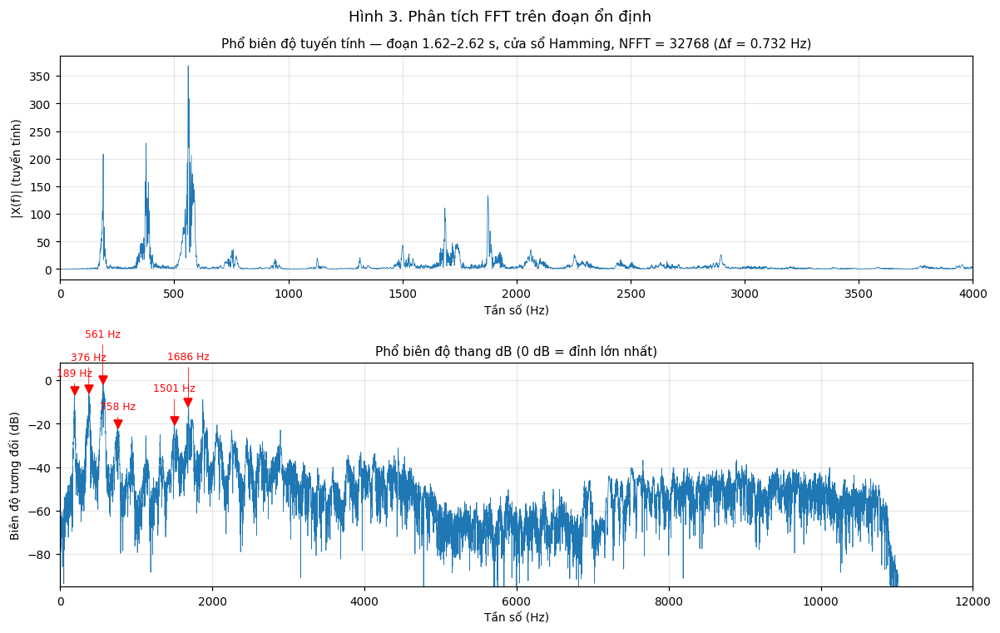

In [7]:
f, mag, db = S[32768]
pk, _ = find_peaks(db, height=-32, distance=int(30/(Fs/32768)))
top   = pk[np.argsort(db[pk])[::-1][:8]]
peaks = sorted([(float(f[p]), float(db[p])) for p in top])
f0 = peaks[0][0]

print("Các đỉnh phổ nổi bật:")
for i,(fp,dp) in enumerate(peaks, 1):
    print(f"  {i}. {fp:9.2f} Hz   {dp:7.2f} dB   (≈ {fp/f0:.2f} × f0)")
print(f"\nf0 ước lượng ≈ {f0:.1f} Hz — các đỉnh 2f0, 3f0 xuất hiện rõ => cấu trúc điều hòa.")
print("Lưu ý: đây là nhạc đa nguồn, không quy toàn bộ các đỉnh cho một nguồn âm duy nhất.")

fig, ax = plt.subplots(2, 1, figsize=(11, 7))
ax[0].plot(f, mag, lw=0.5, color="#1f77b4")
ax[0].set_xlim(0, 4000); ax[0].set_xlabel("Tần số (Hz)"); ax[0].set_ylabel("|X(f)| (tuyến tính)")
ax[0].set_title(f"Phổ biên độ tuyến tính — đoạn {T0:.2f}–{T0+SEG_DUR:.2f} s, cửa sổ Hamming, "
                f"NFFT = 32768 (Δf = {Fs/32768:.3f} Hz)", fontsize=10)
ax[1].plot(f, db, lw=0.5, color="#1f77b4")
for i,(fp,dp) in enumerate(peaks[:6]):
    ax[1].plot(fp, dp, "rv", ms=6)
    ax[1].annotate(f"{fp:.0f} Hz", (fp, dp), textcoords="offset points",
                   xytext=(0, 12+11*(i % 3)), ha="center", fontsize=8, color="r",
                   arrowprops=dict(arrowstyle="-", color="r", lw=0.5))
ax[1].set_xlim(0, Fs/2); ax[1].set_ylim(-95, 8)
ax[1].set_xlabel("Tần số (Hz)"); ax[1].set_ylabel("Biên độ tương đối (dB)")
ax[1].set_title("Phổ biên độ thang dB (0 dB = đỉnh lớn nhất)", fontsize=10)
fig.suptitle("Hình 3. Phân tích FFT trên đoạn ổn định", fontsize=12)
fig.tight_layout(); fig.savefig(f"{FIG}/03_fft_spectrum.png"); plt.show()
RESULTS["fft"] = dict(T0=T0, peaks=peaks, f0=f0, df={nf: Fs/nf for nf in NFFTS},
                      true_res=2*Fs/Lseg)

In [8]:
# Băng thông hiệu dụng thực sự của tệp MP3 (ước lượng bằng Welch PSD trên cả tệp)
fw, Pw = signal.welch(x, Fs, nperseg=8192)
dw = 10*np.log10(Pw + 1e-20); dw -= dw.max()
ref = float(np.median(dw[(fw > 1000) & (fw < 5000)]))
cutoff = float(fw[np.where(dw > ref-25)[0][-1]])
print(f"Băng thông hiệu dụng ≈ {cutoff:,.0f} Hz  (Nyquist lý thuyết = {Fs/2:,.0f} Hz)")
print(f"=> Bộ mã hóa MP3 đã cắt thêm khoảng {Fs/2-cutoff:,.0f} Hz dưới Nyquist để tiết kiệm bit.")
RESULTS["bandwidth_Hz"] = cutoff

Băng thông hiệu dụng ≈ 10,951 Hz  (Nyquist lý thuyết = 12,000 Hz)
=> Bộ mã hóa MP3 đã cắt thêm khoảng 1,049 Hz dưới Nyquist để tiết kiệm bit.


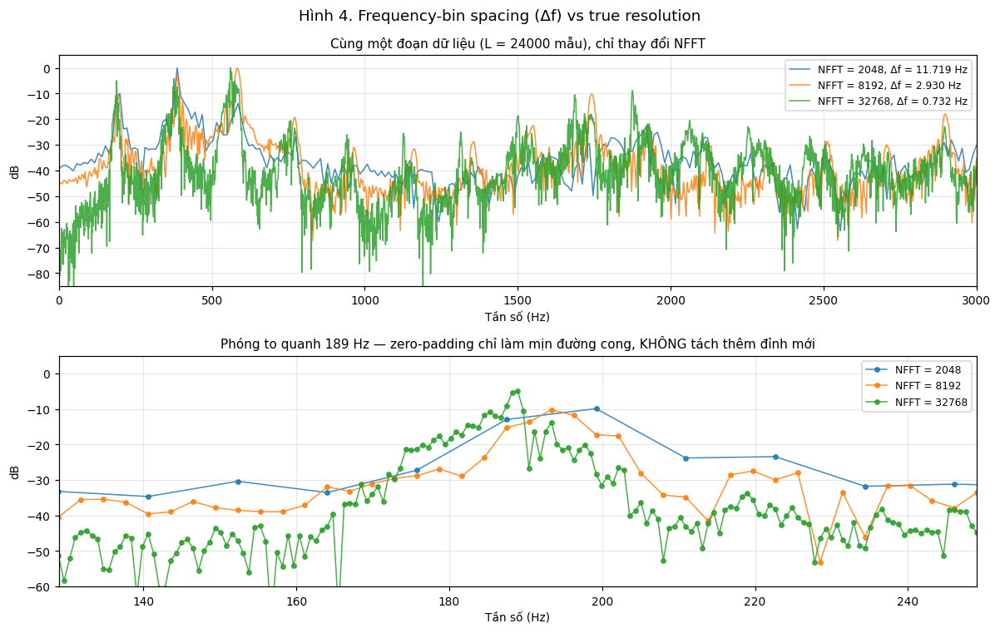

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(11, 7))
for nf, c in zip(NFFTS, ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    ff, _, dd = S[nf]
    ax[0].plot(ff, dd, lw=1.0, color=c, alpha=0.85, label=f"NFFT = {nf}, Δf = {Fs/nf:.3f} Hz")
    ax[1].plot(ff, dd, "o-", ms=3.5, lw=1.0, color=c, alpha=0.85, label=f"NFFT = {nf}")
ax[0].set_xlim(0, 3000); ax[0].set_ylim(-85, 5); ax[0].legend(fontsize=8)
ax[0].set_xlabel("Tần số (Hz)"); ax[0].set_ylabel("dB")
ax[0].set_title(f"Cùng một đoạn dữ liệu (L = {Lseg} mẫu), chỉ thay đổi NFFT", fontsize=10)
ax[1].set_xlim(f0-60, f0+60); ax[1].set_ylim(-60, 5); ax[1].legend(fontsize=8)
ax[1].set_xlabel("Tần số (Hz)"); ax[1].set_ylabel("dB")
ax[1].set_title(f"Phóng to quanh {f0:.0f} Hz — zero-padding chỉ làm mịn đường cong, "
                f"KHÔNG tách thêm đỉnh mới", fontsize=10)
fig.suptitle("Hình 4. Frequency-bin spacing (Δf) vs true resolution", fontsize=12)
fig.tight_layout(); fig.savefig(f"{FIG}/04_nfft_compare.png"); plt.show()

**Nhận xét C.**
1. Ba đỉnh mạnh nhất nằm ở khoảng $f_0$, $2f_0$, $3f_0$ — chuỗi điều hòa rõ rệt, đúng với một nhạc cụ có cao độ xác định.
2. Tăng NFFT từ 2048 → 32768 làm $\Delta f$ giảm 16 lần (11.7 → 0.73 Hz), nhưng ở hình 4 (dưới) ba đường
   **nằm chồng lên cùng một hình dạng main-lobe**: không có đỉnh nào tách ra thêm. Đó là bằng chứng trực tiếp
   rằng zero-padding chỉ nội suy, độ phân giải thực vẫn là ≈ $2F_s/L$.
3. Phổ rơi thẳng đứng ở khoảng 11 kHz — thấp hơn Nyquist 12 kHz. Đây là **dấu vết của bộ mã hóa MP3**:
   encoder chủ động lowpass để dồn bit cho dải nghe được quan trọng hơn.

---
## D. STFT và spectrogram

$$X[m,k]=\sum_n x[n]\,w[n-mH]\,e^{-j2\pi kn/N_{FFT}},\qquad
S_{dB}[m,k]=20\log_{10}(|X[m,k]|+\varepsilon)$$

Cấu hình chuẩn của xử lý tiếng nói: frame $\approx$ 25 ms, hop $\approx$ 10 ms.

L = 0.025·Fs = 600 mẫu | H = 0.010·Fs = 240 mẫu
Overlap = L − H = 360 mẫu = 60%
Số frame ≈ 1539  |  tốc độ khung = 100 frame/s
Δf_true ≈ 2·Fs/L = 80 Hz


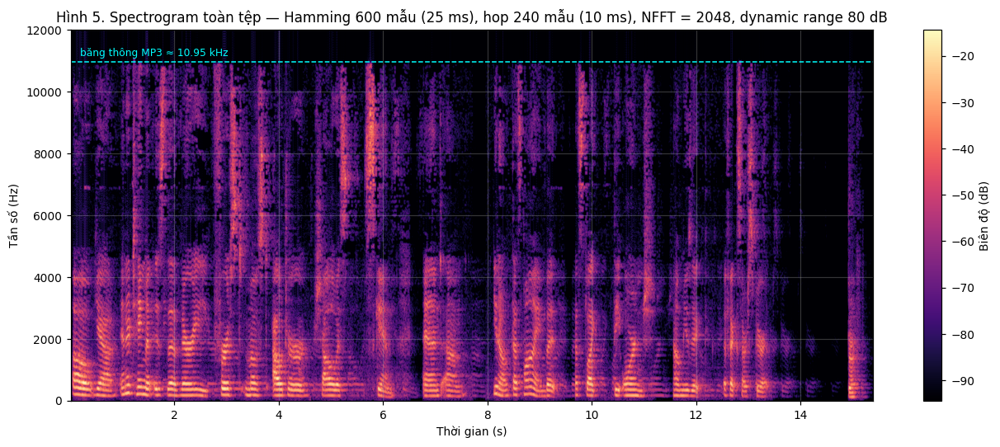

In [10]:
Lw = round(0.025*Fs)    # frame 25 ms
Hp = round(0.010*Fs)    # hop 10 ms
print(f"L = 0.025·Fs = {Lw} mẫu | H = 0.010·Fs = {Hp} mẫu")
print(f"Overlap = L − H = {Lw-Hp} mẫu = {100*(Lw-Hp)/Lw:.0f}%")
print(f"Số frame ≈ {1 + (N-Lw)//Hp}  |  tốc độ khung = {Fs/Hp:.0f} frame/s")
print(f"Δf_true ≈ 2·Fs/L = {2*Fs/Lw:.0f} Hz")

f, tt, Z = signal.stft(x, Fs, window="hamming", nperseg=Lw, noverlap=Lw-Hp,
                       nfft=2048, boundary=None, padded=False)
ZdB = 20*np.log10(np.abs(Z) + 1e-10)
VMAX = ZdB.max(); VMIN = VMAX - 80     # dynamic range cố định 80 dB

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.pcolormesh(tt, f, ZdB, shading="gouraud", cmap="magma", vmin=VMIN, vmax=VMAX)
ax.axhline(cutoff, color="cyan", ls="--", lw=1)
ax.text(0.2, cutoff+200, f"băng thông MP3 ≈ {cutoff/1000:.2f} kHz", color="cyan", fontsize=8)
ax.set_xlabel("Thời gian (s)"); ax.set_ylabel("Tần số (Hz)")
ax.set_title(f"Hình 5. Spectrogram toàn tệp — Hamming {Lw} mẫu (25 ms), hop {Hp} mẫu (10 ms), "
             f"NFFT = 2048, dynamic range 80 dB", fontsize=11)
fig.colorbar(im, ax=ax, label="Biên độ (dB)")
fig.tight_layout(); fig.savefig(f"{FIG}/05_spectrogram_25ms.png"); plt.show()

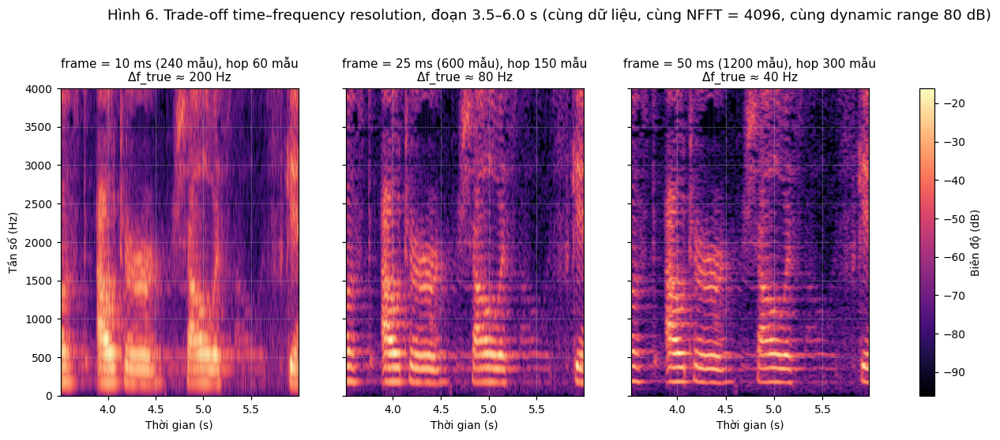

In [11]:
ZOOM = (3.5, 6.0)
xs = x[int(ZOOM[0]*Fs):int(ZOOM[1]*Fs)]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for a, ms in zip(ax, [10, 25, 50]):
    Ln = round(ms/1000*Fs); Hn = max(1, Ln//4)
    ff, ttz, Zz = signal.stft(xs, Fs, window="hamming", nperseg=Ln, noverlap=Ln-Hn,
                              nfft=4096, boundary=None, padded=False)
    D = 20*np.log10(np.abs(Zz) + 1e-10)
    im = a.pcolormesh(ttz+ZOOM[0], ff, D, shading="gouraud", cmap="magma",
                      vmin=D.max()-80, vmax=D.max())     # CÙNG dynamic range 80 dB
    a.set_ylim(0, 4000); a.set_xlabel("Thời gian (s)")
    a.set_title(f"frame = {ms} ms ({Ln} mẫu), hop {Hn} mẫu\nΔf_true ≈ {2*Fs/Ln:.0f} Hz", fontsize=10)
ax[0].set_ylabel("Tần số (Hz)")
fig.colorbar(im, ax=ax, label="Biên độ (dB)")
fig.suptitle(f"Hình 6. Trade-off time–frequency resolution, đoạn {ZOOM[0]}–{ZOOM[1]} s "
             f"(cùng dữ liệu, cùng NFFT = 4096, cùng dynamic range 80 dB)", fontsize=12, y=1.08)
fig.savefig(f"{FIG}/06_frame_length_compare.png"); plt.show()

**Nhận xét D.**
1. Spectrogram toàn tệp cho thấy năng lượng tập trung mạnh dưới 2 kHz, các vạch điều hòa nằm ngang song song,
   xen kẽ các **vạch dọc** — đó là transient (tiếng gảy/gõ) trải rộng trên mọi tần số trong thời gian rất ngắn.
2. So sánh ba frame length (cùng dữ liệu, cùng NFFT, cùng dynamic range — điều kiện của controlled experiment):
   - **10 ms**: các vạch dọc sắc nét (định vị thời gian tốt), nhưng các hoạ âm bị nhoè thành mảng liên tục.
   - **50 ms**: các vạch điều hòa nằm ngang tách bạch rõ ràng, nhưng thời điểm bắt đầu của mỗi nốt bị kéo giãn/mờ đi.
   - **25 ms**: điểm cân bằng, đủ mịn theo tần số mà vẫn thấy được nhịp — đây là lý do 25 ms là cấu hình
     mặc định trong xử lý tiếng nói.
3. Quan hệ định lượng: $\Delta f_{true}$ tỉ lệ nghịch với $L$ (200 / 80 / 40 Hz cho 10 / 25 / 50 ms),
   trong khi độ phân giải thời gian tỉ lệ thuận với $L$. Không thể cải thiện đồng thời cả hai —
   đây là hệ quả của nguyên lý bất định thời gian–tần số.

---
## E. Thí nghiệm cửa sổ: rectangular vs Hamming

$$w_{Hamming}[n]=0.54-0.46\cos\!\Big(\frac{2\pi n}{L-1}\Big),\quad 0\le n\le L-1$$

Cắt một frame bằng cửa sổ chữ nhật tương đương nhân với hàm cổng → trong miền tần số là **tích chập với**
$W(e^{j\omega})$ có side-lobe cao ⇒ năng lượng của một thành phần "rò" sang các bin khác (*spectral leakage*).

In [12]:
Lwin = Lw          # dùng chính frame 25 ms của STFT
frame = x[int(T0*Fs):int(T0*Fs)+Lwin]
NFFT_W = 16384
w_rect, w_hamm = np.ones(Lwin), np.hamming(Lwin)

def window_response(w, nfft=65536):
    W = np.abs(np.fft.rfft(w/w.sum(), n=nfft))
    d = 20*np.log10(W + 1e-15); d -= d.max()
    ff = np.fft.rfftfreq(nfft, 1/Fs)
    i = 1                                   # tìm null đầu tiên
    while i < len(d)-1 and not (d[i] < d[i-1] and d[i] < d[i+1]):
        i += 1
    return ff, d, 2*ff[i], float(np.max(d[i:]))   # (main-lobe null-null, side-lobe cao nhất)

fr_, dr_, ml_r, sl_r = window_response(w_rect)
fh_, dh_, ml_h, sl_h = window_response(w_hamm)
print(f"Rectangular : main-lobe (null–null) = {ml_r:6.1f} Hz | side-lobe cao nhất = {sl_r:6.1f} dB")
print(f"Hamming     : main-lobe (null–null) = {ml_h:6.1f} Hz | side-lobe cao nhất = {sl_h:6.1f} dB")
print(f"=> Hamming đổi main-lobe rộng gấp {ml_h/ml_r:.1f} lần lấy side-lobe thấp hơn {sl_r-sl_h:.1f} dB.")

def sp_(sig):
    X = np.abs(np.fft.rfft(sig, n=NFFT_W))
    return np.fft.rfftfreq(NFFT_W, 1/Fs), 20*np.log10(X + 1e-15)

fx, d_rect = sp_(frame*w_rect); _, d_hamm = sp_(frame*w_hamm)
ref0 = max(d_rect.max(), d_hamm.max()); d_rect -= ref0; d_hamm -= ref0

Rectangular : main-lobe (null–null) =   79.8 Hz | side-lobe cao nhất =  -13.3 dB
Hamming     : main-lobe (null–null) =  160.4 Hz | side-lobe cao nhất =  -42.7 dB
=> Hamming đổi main-lobe rộng gấp 2.0 lần lấy side-lobe thấp hơn 29.4 dB.


2–5 kHz: rect -40.2 dB vs Hamming -46.5 dB  (chênh +6.3 dB)
5–10 kHz: rect -50.7 dB vs Hamming -65.6 dB  (chênh +14.9 dB)


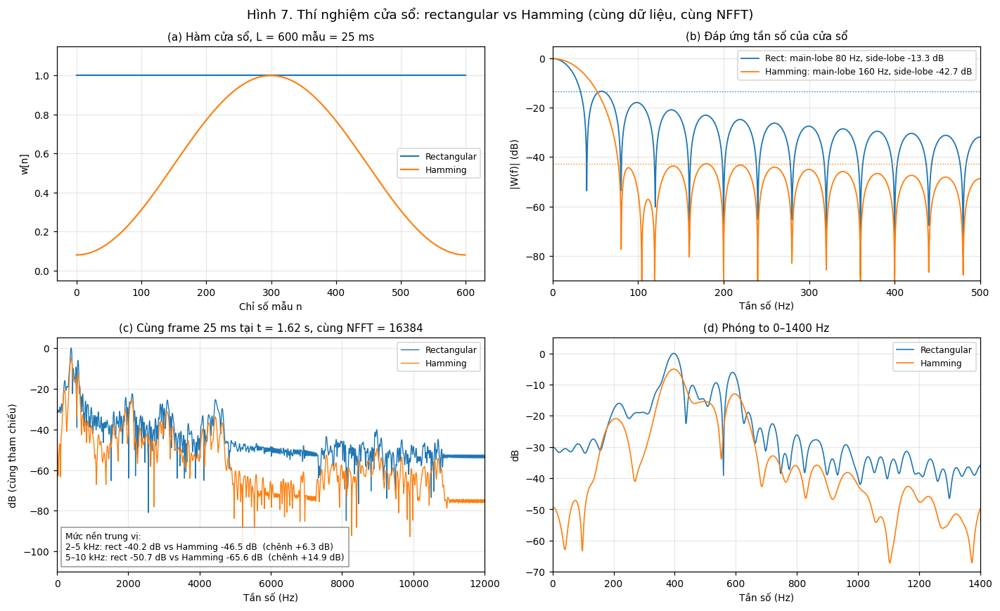

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
n_ = np.arange(Lwin)
ax[0,0].plot(n_, w_rect, lw=1.4, label="Rectangular")
ax[0,0].plot(n_, w_hamm, lw=1.4, label="Hamming")
ax[0,0].set_ylim(-.05, 1.15); ax[0,0].set_xlabel("Chỉ số mẫu n"); ax[0,0].set_ylabel("w[n]")
ax[0,0].set_title(f"(a) Hàm cửa sổ, L = {Lwin} mẫu = 25 ms", fontsize=10); ax[0,0].legend(fontsize=8)

ax[0,1].plot(fr_, dr_, lw=1.2, label=f"Rect: main-lobe {ml_r:.0f} Hz, side-lobe {sl_r:.1f} dB")
ax[0,1].plot(fh_, dh_, lw=1.2, label=f"Hamming: main-lobe {ml_h:.0f} Hz, side-lobe {sl_h:.1f} dB")
ax[0,1].axhline(sl_r, color="#1f77b4", ls=":", lw=.9); ax[0,1].axhline(sl_h, color="#ff7f0e", ls=":", lw=.9)
ax[0,1].set_xlim(0, 500); ax[0,1].set_ylim(-90, 5)
ax[0,1].set_xlabel("Tần số (Hz)"); ax[0,1].set_ylabel("|W(f)| (dB)")
ax[0,1].set_title("(b) Đáp ứng tần số của cửa sổ", fontsize=10); ax[0,1].legend(fontsize=8)

ax[1,0].plot(fx, d_rect, lw=0.9, color="#1f77b4", label="Rectangular")
ax[1,0].plot(fx, d_hamm, lw=0.9, color="#ff7f0e", label="Hamming")
ax[1,0].set_xlim(0, Fs/2); ax[1,0].set_ylim(-110, 5)
ax[1,0].set_xlabel("Tần số (Hz)"); ax[1,0].set_ylabel("dB (cùng tham chiếu)")
ax[1,0].set_title(f"(c) Cùng frame 25 ms tại t = {T0:.2f} s, cùng NFFT = {NFFT_W}", fontsize=10)
ax[1,0].legend(fontsize=8)

ax[1,1].plot(fx, d_rect, lw=1.1, color="#1f77b4", label="Rectangular")
ax[1,1].plot(fx, d_hamm, lw=1.1, color="#ff7f0e", label="Hamming")
ax[1,1].set_xlim(0, 1400); ax[1,1].set_ylim(-70, 5)
ax[1,1].set_xlabel("Tần số (Hz)"); ax[1,1].set_ylabel("dB")
ax[1,1].set_title("(d) Phóng to 0–1400 Hz", fontsize=10); ax[1,1].legend(fontsize=8)

lines = []
for lab, m in [("2–5 kHz", (fx>2000)&(fx<5000)), ("5–10 kHz", (fx>5000)&(fx<10000))]:
    a_, b_ = float(np.median(d_rect[m])), float(np.median(d_hamm[m]))
    lines.append(f"{lab}: rect {a_:.1f} dB vs Hamming {b_:.1f} dB  (chênh {a_-b_:+.1f} dB)")
    RESULTS.setdefault("leakage", {})[lab] = dict(rect=a_, hamming=b_)
ax[1,0].text(.02, .04, "Mức nền trung vị:\n" + "\n".join(lines), transform=ax[1,0].transAxes,
             fontsize=8, va="bottom", bbox=dict(fc="w", alpha=.85, ec="gray"))
print("\n".join(lines))
fig.suptitle("Hình 7. Thí nghiệm cửa sổ: rectangular vs Hamming (cùng dữ liệu, cùng NFFT)", fontsize=12)
fig.tight_layout(); fig.savefig(f"{FIG}/07_window_compare.png"); plt.show()
RESULTS["window"] = dict(rect=dict(mainlobe=ml_r, sidelobe=sl_r),
                         hamming=dict(mainlobe=ml_h, sidelobe=sl_h))

**Nhận xét E.**
1. Hình (b) tái hiện đúng lý thuyết: side-lobe đầu tiên của cửa sổ chữ nhật ở $\approx -13.3$ dB,
   của Hamming ở $\approx -42.7$ dB (thấp hơn gần 30 dB), đổi lại main-lobe rộng gấp đôi.
2. Hình (c): trên **cùng một frame, cùng NFFT**, đường rectangular có mức nền cao hơn Hamming khoảng
   6 dB ở dải 2–5 kHz và tới ~15 dB ở dải 5–10 kHz (số đo in ngay dưới ô code). Phần chênh lệch đó
   **không phải tín hiệu thật** mà là năng lượng rò từ các đỉnh mạnh ở dải thấp — nếu dùng rectangular
   ta sẽ kết luận sai rằng tệp có nhiều năng lượng cao tần.
3. Hình (d): các đỉnh của Hamming tròn và rộng hơn. Nếu hai hoạ âm cách nhau nhỏ hơn main-lobe 160 Hz,
   Hamming sẽ gộp chúng thành một, trong khi rectangular (main-lobe 80 Hz) vẫn tách được — đây chính là cái giá
   phải trả để đổi lấy leakage thấp.

---
## F. Lọc số FIR

$$y[n]=\sum_{r=0}^{M}b_r\,x[n-r],\qquad H(e^{j\omega})=\sum_{r=0}^{M}b_r e^{-j\omega r}$$

FIR đối xứng $L$ taps có **pha tuyến tính** ⇒ group delay không đổi $=(L-1)/2$ mẫu.
Điều này quan trọng: nếu không bù trễ, mọi phép so sánh dạng sóng hay tính SNR giữa trước/sau lọc đều sai.

Số taps = 201 (lẻ, đối xứng ⇒ FIR Type I, pha tuyến tính)
Group delay = (L−1)/2 = 100 mẫu = 4.17 ms


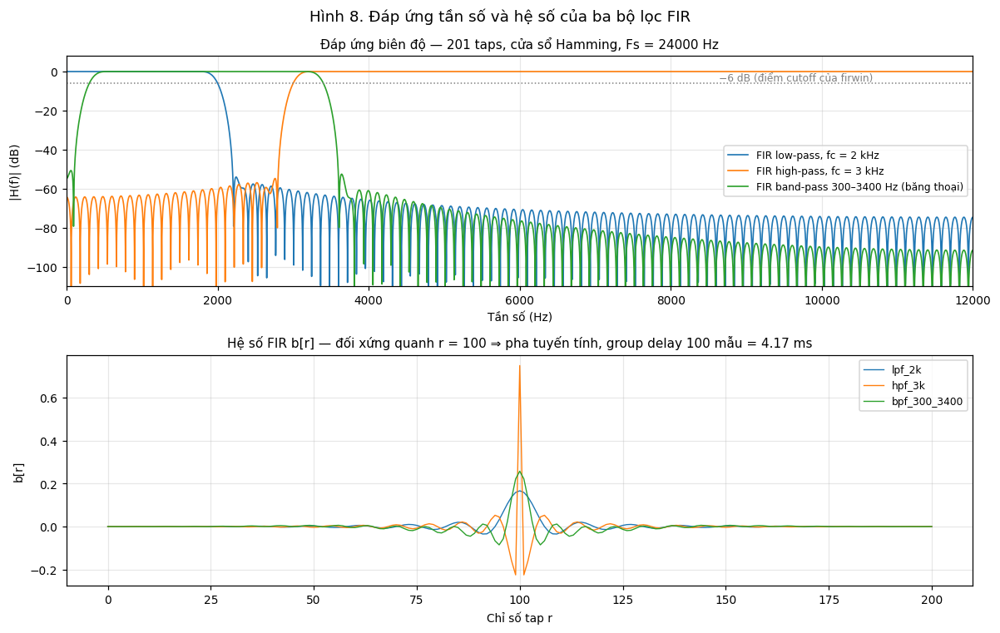

,|H| @ 500 Hz,|H| @ 1000 Hz,|H| @ 2000 Hz,|H| @ 3000 Hz,|H| @ 4000 Hz,|H| @ 6000 Hz
lpf_2k,-0.00,-0.01,-6.03,-75.69,-66.72,-76.80
hpf_3k,-65.34,-69.47,-65.24,-6.02,-0.00,0.00
bpf_300_3400,-0.04,-0.03,-0.02,-0.01,-61.11,-78.58


In [14]:
NUMTAPS = 201
gd = (NUMTAPS-1)//2
print(f"Số taps = {NUMTAPS} (lẻ, đối xứng ⇒ FIR Type I, pha tuyến tính)")
print(f"Group delay = (L−1)/2 = {gd} mẫu = {1000*gd/Fs:.2f} ms")

FILTERS = {
    "lpf_2k":       (signal.firwin(NUMTAPS, 2000, fs=Fs, window="hamming"),
                     "FIR low-pass, fc = 2 kHz"),
    "hpf_3k":       (signal.firwin(NUMTAPS, 3000, fs=Fs, window="hamming", pass_zero=False),
                     "FIR high-pass, fc = 3 kHz"),
    "bpf_300_3400": (signal.firwin(NUMTAPS, [300, 3400], fs=Fs, window="hamming", pass_zero=False),
                     "FIR band-pass 300–3400 Hz (băng thoại)"),
}

fig, ax = plt.subplots(2, 1, figsize=(11, 7))
for key, (b, lab) in FILTERS.items():
    wf, Hf = signal.freqz(b, [1.0], worN=8192, fs=Fs)
    HdB = 20*np.log10(np.abs(Hf) + EPS)
    ax[0].plot(wf, HdB, lw=1.1, label=lab)
    ax[1].plot(np.arange(NUMTAPS), b, lw=0.9, label=key)
    RESULTS.setdefault("filters", {})[key] = {
        f"|H| @ {fq} Hz": round(float(np.interp(fq, wf, HdB)), 2)
        for fq in (500, 1000, 2000, 3000, 4000, 6000)}
ax[0].axhline(-6.02, color="gray", ls=":", lw=1)
ax[0].text(Fs/2*0.72, -5, "−6 dB (điểm cutoff của firwin)", fontsize=8, color="gray")
ax[0].set_xlim(0, Fs/2); ax[0].set_ylim(-110, 8)
ax[0].set_xlabel("Tần số (Hz)"); ax[0].set_ylabel("|H(f)| (dB)")
ax[0].set_title(f"Đáp ứng biên độ — {NUMTAPS} taps, cửa sổ Hamming, Fs = {Fs} Hz", fontsize=10)
ax[0].legend(fontsize=8)
ax[1].set_xlabel("Chỉ số tap r"); ax[1].set_ylabel("b[r]")
ax[1].set_title(f"Hệ số FIR b[r] — đối xứng quanh r = {gd} ⇒ pha tuyến tính, "
                f"group delay {gd} mẫu = {1000*gd/Fs:.2f} ms", fontsize=10)
ax[1].legend(fontsize=8)
fig.suptitle("Hình 8. Đáp ứng tần số và hệ số của ba bộ lọc FIR", fontsize=12)
fig.tight_layout(); fig.savefig(f"{FIG}/08_filter_response.png"); plt.show()

import pandas as pd
display(pd.DataFrame(RESULTS["filters"]).T)

→ đã ghi audio/music_lpf_2k.wav
→ đã ghi audio/music_hpf_3k.wav
→ đã ghi audio/music_bpf_300_3400.wav


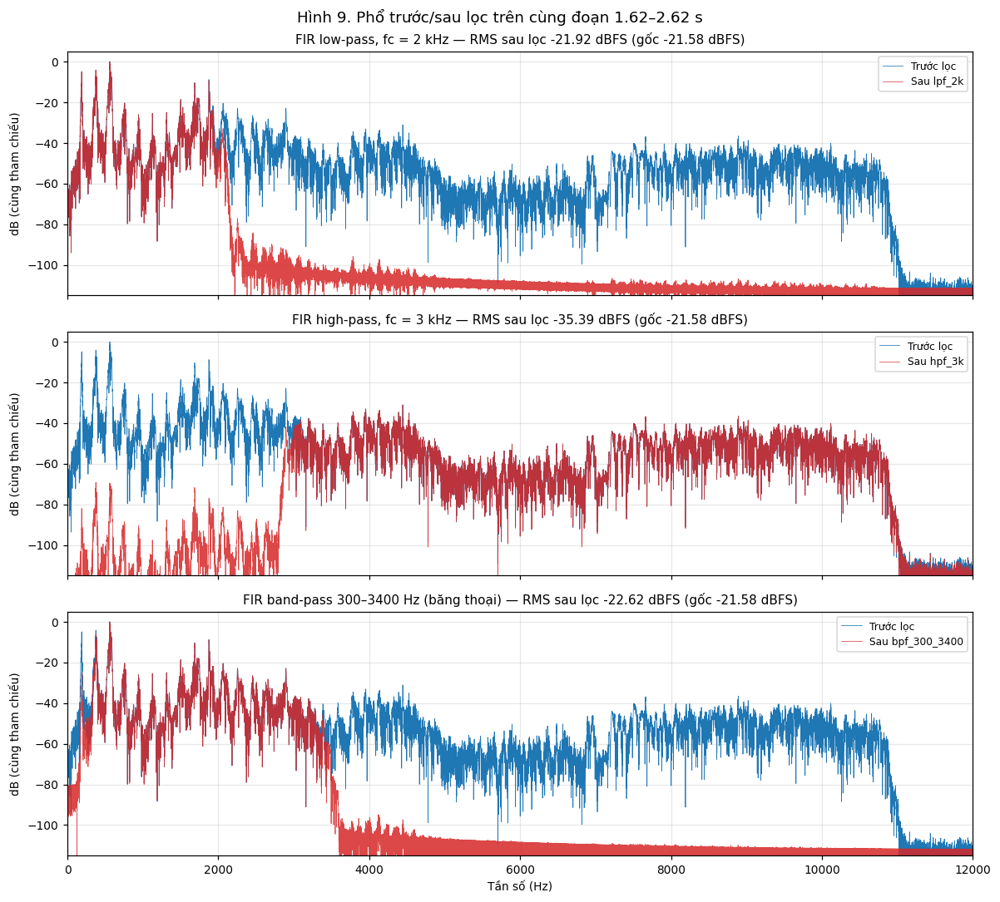

In [15]:
w_seg = np.hamming(Lseg)
NFFT_F = 32768
def seg_spec(sig):
    X = np.abs(np.fft.rfft(sig*w_seg, n=NFFT_F))
    return np.fft.rfftfreq(NFFT_F, 1/Fs), 20*np.log10(X + EPS)

f_ref, d_ref = seg_spec(seg); ref_max = d_ref.max()

fig, ax = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
for a, (key, (b, lab)) in zip(ax, FILTERS.items()):
    y = signal.lfilter(b, [1.0], x)
    y = np.concatenate([y[gd:], np.zeros(gd)])            # BÙ group delay
    sf.write(f"{AUD}/music_{key}.wav", np.clip(y, -1, 1).astype(np.float32), Fs, subtype="PCM_16")
    seg_y = y[int(T0*Fs):int((T0+SEG_DUR)*Fs)]
    f1, d1 = seg_spec(seg_y)
    a.plot(f_ref, d_ref-ref_max, lw=0.5, color="#1f77b4", label="Trước lọc")
    a.plot(f1,    d1-ref_max,   lw=0.5, color="#d62728", alpha=0.85, label=f"Sau {key}")
    a.set_ylim(-115, 5); a.set_xlim(0, Fs/2); a.set_ylabel("dB (cùng tham chiếu)")
    a.set_title(f"{lab} — RMS sau lọc {dbfs(np.sqrt(np.mean(y**2))):.2f} dBFS "
                f"(gốc {dbfs(sM['rms']):.2f} dBFS)", fontsize=10)
    a.legend(fontsize=8)
    RESULTS["filters"][key]["RMS_out_dBFS"] = round(float(dbfs(np.sqrt(np.mean(y**2)))), 2)
    print(f"→ đã ghi audio/music_{key}.wav")
ax[-1].set_xlabel("Tần số (Hz)")
fig.suptitle(f"Hình 9. Phổ trước/sau lọc trên cùng đoạn {T0:.2f}–{T0+SEG_DUR:.2f} s", fontsize=12)
fig.tight_layout(); fig.savefig(f"{FIG}/09_filter_before_after.png"); plt.show()

In [16]:
print("Nghe thử (theo thứ tự: gốc → low-pass 2 kHz → high-pass 3 kHz → band-pass thoại)")
display(Audio(x, rate=Fs))
for key in FILTERS:
    d_, sr_ = sf.read(f"{AUD}/music_{key}.wav"); display(Audio(d_, rate=sr_))

Nghe thử (theo thứ tự: gốc → low-pass 2 kHz → high-pass 3 kHz → band-pass thoại)


**Nhận xét F.**
1. Phổ sau lọc **bám sát đúng $H(f)$ đã thiết kế**: với LPF 2 kHz, mọi thành phần trên khoảng 2.3 kHz bị dìm
   xuống dưới −75 dB; với HPF 3 kHz, dải dưới 1 kHz bị suy giảm gần −70 dB. Đây là kiểm chứng trực tiếp
   của $Y(e^{j\omega}) = H(e^{j\omega})X(e^{j\omega})$.
2. Cảm nhận nghe khớp với phổ: bản LPF nghe **tối/đục (muffled)** vì mất hết phụ âm và phần sáng của nhạc cụ;
   bản HPF nghe **mỏng, mất hết bass**, RMS tụt khoảng 14 dB — đúng vì phần lớn năng lượng của tệp nằm dưới 2 kHz;
   bản BPF 300–3400 Hz nghe như qua điện thoại.
3. `firwin` định nghĩa cutoff tại điểm **−6 dB** chứ không phải −3 dB; đo trên $H(f)$ đúng là −6.03 dB tại 2 kHz.
   Vùng chuyển tiếp rộng khoảng 300 Hz là hệ quả của số taps hữu hạn và cửa sổ Hamming.
4. Trước khi so sánh dạng sóng, đã **dịch tín hiệu ra đi 100 mẫu** để bù group delay. Nếu bỏ qua bước này,
   sai số do lệch thời gian sẽ lớn hơn nhiều so với sai số do chính bộ lọc gây ra.

---
## G. Lượng tử hóa, resampling và mã hóa

### G.1 Lượng tử hóa đều và SNR

$$L=2^B,\quad \Delta=\frac{2X_{max}}{2^B},\quad e[n]=\hat x[n]-x[n],\quad \sigma_e^2\approx\frac{\Delta^2}{12}$$
$$\mathrm{SNR}=10\log_{10}\frac{\sum x^2[n]}{\sum (\hat x[n]-x[n])^2}\ \text{(dB)},\qquad
\mathrm{SNR}_Q\approx 6.02B+4.77-20\log_{10}\!\frac{X_{max}}{\sigma_x}$$

In [17]:
def quantize(v, B):
    qmax = 2**(B-1) - 1
    return np.round(np.clip(v, -1, 1)*qmax) / qmax

def snr_db(v, vq):
    e = vq - v
    return 10*np.log10(np.sum(v*v) / np.sum(e*e))

sigma_x  = float(np.sqrt(np.mean(x**2)))
headroom = 20*np.log10(1.0/sigma_x)          # = 20log10(Xmax/σx) với Xmax = 1
print(f"σx (RMS) = {sigma_x:.5f}  ->  20·log10(Xmax/σx) = {headroom:.2f} dB")
print(f"Crest factor = {dbfs(sM['peak'])-dbfs(sigma_x):.2f} dB\n")

BITS = [2, 4, 6, 8, 12, 16]
rows = []
for B in BITS:
    xq  = quantize(x, B)
    s   = snr_db(x, xq)
    th  = 6.02*B + 4.77 - headroom
    rows.append(dict(B=B, L=2**B, Delta=2/(2**B - 2), SNR_do=s, SNR_lythuyet=th,
                     sai_lech=s-th, RMS_loi=float(np.sqrt(np.mean((xq-x)**2)))))
    if B in (4, 8, 16):
        sf.write(f"{AUD}/music_{B}bit.wav", xq.astype(np.float32), Fs, subtype="PCM_16")

import pandas as pd
dfq = pd.DataFrame(rows)
display(dfq.style.format({"Delta":"{:.6f}", "SNR_do":"{:.2f}", "SNR_lythuyet":"{:.2f}",
                          "sai_lech":"{:+.2f}", "RMS_loi":"{:.2e}"}))
slope_all  = np.polyfit(BITS, dfq.SNR_do, 1)[0]
m4 = dfq.B >= 4
slope_4_16 = np.polyfit(dfq.B[m4], dfq.SNR_do[m4], 1)[0]
print(f"\nĐộ dốc hồi quy (B = 2…16) : {slope_all:.2f} dB/bit")
print(f"Độ dốc hồi quy (B = 4…16) : {slope_4_16:.2f} dB/bit   (lý thuyết: 6.02 dB/bit)")
RESULTS["quantization"] = dict(rows=rows, slope_all=float(slope_all),
                               slope_4_16=float(slope_4_16), sigma_x=sigma_x,
                               headroom_dB=float(headroom))

σx (RMS) = 0.08341  ->  20·log10(Xmax/σx) = 21.58 dB
Crest factor = 20.34 dB



,B,L,Delta,SNR_do,SNR_lythuyet,sai_lech,RMS_loi
0,2,4,1.000000,0.13,-4.77,+4.90,8.22e-02
1,4,16,0.142857,8.86,7.27,+1.59,3.01e-02
2,6,64,0.032258,20.17,19.31,+0.85,8.18e-03
3,8,256,0.007874,31.74,31.35,+0.39,2.16e-03
4,12,4096,0.000489,55.49,55.43,+0.06,1.40e-04
5,16,65536,0.000031,78.37,79.51,-1.14,1.01e-05



Độ dốc hồi quy (B = 2…16) : 5.68 dB/bit
Độ dốc hồi quy (B = 4…16) : 5.81 dB/bit   (lý thuyết: 6.02 dB/bit)


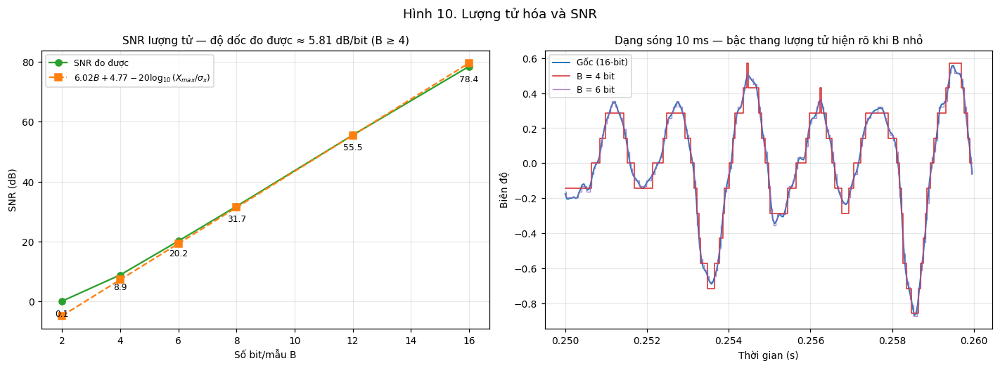

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].plot(dfq.B, dfq.SNR_do, "o-", color="#2ca02c", label="SNR đo được")
ax[0].plot(dfq.B, dfq.SNR_lythuyet, "s--", color="#ff7f0e",
           label=r"$6.02B+4.77-20\log_{10}(X_{max}/\sigma_x)$")
for b_, s_ in zip(dfq.B, dfq.SNR_do):
    ax[0].annotate(f"{s_:.1f}", (b_, s_), textcoords="offset points", xytext=(0,-14),
                   fontsize=8, ha="center")
ax[0].set_xlabel("Số bit/mẫu B"); ax[0].set_ylabel("SNR (dB)")
ax[0].set_title(f"SNR lượng tử — độ dốc đo được ≈ {slope_4_16:.2f} dB/bit (B ≥ 4)", fontsize=10)
ax[0].legend(fontsize=8)

ZT = float(t_fr[i_hi])                    # lấy đoạn to nhất để thấy rõ bậc thang
i0, i1 = int(ZT*Fs), int(ZT*Fs)+240       # 10 ms
ax[1].plot(t[i0:i1], x[i0:i1], lw=1.3, label="Gốc (16-bit)", color="#1f77b4")
ax[1].step(t[i0:i1], quantize(x,4)[i0:i1], where="mid", lw=1.0, label="B = 4 bit", color="#d62728")
ax[1].step(t[i0:i1], quantize(x,6)[i0:i1], where="mid", lw=0.9, label="B = 6 bit", color="#9467bd", alpha=.8)
ax[1].set_xlabel("Thời gian (s)"); ax[1].set_ylabel("Biên độ")
ax[1].set_title("Dạng sóng 10 ms — bậc thang lượng tử hiện rõ khi B nhỏ", fontsize=10)
ax[1].legend(fontsize=8)
fig.suptitle("Hình 10. Lượng tử hóa và SNR", fontsize=12)
fig.tight_layout(); fig.savefig(f"{FIG}/10_quantization_snr.png"); plt.show()

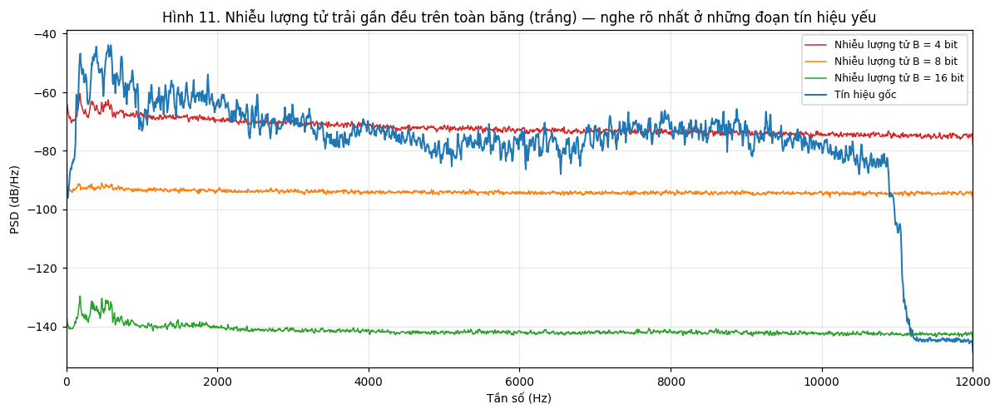

Nghe thử: 16-bit → 8-bit → 4-bit (chú ý tiếng rè nền ở đoạn nhỏ tiếng/đuôi tắt dần)


In [19]:
fig, ax = plt.subplots(figsize=(11, 4.6))
for B, c in zip([4, 8, 16], ["#d62728", "#ff7f0e", "#2ca02c"]):
    f_, P_ = signal.welch(quantize(x, B) - x, Fs, nperseg=4096)
    ax.plot(f_, 10*np.log10(P_ + 1e-20), lw=1, color=c, label=f"Nhiễu lượng tử B = {B} bit")
f_, P_ = signal.welch(x, Fs, nperseg=4096)
ax.plot(f_, 10*np.log10(P_ + 1e-20), lw=1.3, color="#1f77b4", label="Tín hiệu gốc")
ax.set_xlim(0, Fs/2); ax.set_xlabel("Tần số (Hz)"); ax.set_ylabel("PSD (dB/Hz)")
ax.set_title("Hình 11. Nhiễu lượng tử trải gần đều trên toàn băng (trắng) — "
             "nghe rõ nhất ở những đoạn tín hiệu yếu", fontsize=11)
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(f"{FIG}/11_quant_noise_psd.png"); plt.show()

print("Nghe thử: 16-bit → 8-bit → 4-bit (chú ý tiếng rè nền ở đoạn nhỏ tiếng/đuôi tắt dần)")
for B in (16, 8, 4):
    d_, sr_ = sf.read(f"{AUD}/music_{B}bit.wav"); display(Audio(d_, rate=sr_))

**Nhận xét G.1.**
1. SNR đo được tăng gần tuyến tính, độ dốc ≈ 5.8 dB/bit với $B \ge 4$ — sát nhưng **không đúng tuyệt đối** 6.02 dB/bit.
2. Vì sao lệch? Mô hình "6 dB/bit" giả định nhiễu lượng tử phân bố đều trên $[-\Delta/2,\Delta/2]$ và
   **không tương quan với tín hiệu**. Giả định này hỏng ở hai đầu:
   - $B$ nhỏ (2–4 bit): chỉ còn 4–16 mức, lỗi lượng tử tương quan mạnh với tín hiệu (méo hài chứ không phải nhiễu trắng),
     và những đoạn rất nhỏ tiếng bị "nuốt" về 0 hoàn toàn.
   - $B$ lớn (16 bit): tín hiệu gốc **vốn đã là PCM 16 bit** được giải mã rồi lấy trung bình hai kênh, nên sàn nhiễu
     của chính nguồn đã nằm ở mức tương đương — SNR đo được (78.4 dB) thấp hơn lý thuyết (79.5 dB).
3. Tín hiệu này có crest factor ≈ 20 dB và $\sigma_x$ chỉ ở mức −21.6 dBFS. Số hạng $-20\log_{10}(X_{max}/\sigma_x)$
   do đó **trừ đi tới 21.6 dB** so với công thức lý tưởng. Đó là lý do một tệp 8 bit chỉ đạt ≈ 32 dB SNR
   chứ không phải ≈ 53 dB.
4. Hình 11 cho thấy nhiễu lượng tử gần như **phẳng trên toàn băng**. Vì vậy ở những đoạn tín hiệu mạnh nó bị che
   (masking), còn ở đoạn lặng/đuôi tắt dần nó lộ ra thành tiếng rè — đúng với những gì nghe thấy.

### G.2 Resampling và aliasing

In [20]:
TARGETS = [24000, 16000, 8000]
for fs2 in TARGETS:
    if fs2 == Fs: continue
    g = np.gcd(fs2, Fs)
    y = signal.resample_poly(x, fs2//g, Fs//g)       # resample_poly có sẵn anti-alias FIR
    sf.write(f"{AUD}/music_{fs2//1000}k.wav", np.clip(y,-1,1).astype(np.float32), fs2, subtype="PCM_16")
    print(f"{Fs} → {fs2} Hz: {len(x):,} mẫu → {len(y):,} mẫu "
          f"(tỉ lệ {fs2//g}/{Fs//g}), RMS {dbfs(np.sqrt(np.mean(y**2))):.2f} dBFS")

# So sánh CÁCH LÀM SAI (bỏ mẫu thủ công) với CÁCH ĐÚNG
x_naive = x[::3]                                      # 24000/3 = 8000 Hz, KHÔNG lọc trước
x_ok    = signal.resample_poly(x, 1, 3)
sf.write(f"{AUD}/music_8k_ALIASED_naive.wav", np.clip(x_naive,-1,1).astype(np.float32), 8000, subtype="PCM_16")

# Chirp kiểm chứng: quét 20 Hz → 11.5 kHz, alias sẽ hiện thành vạch gấp ngược
Tc = 2.0; tc = np.arange(int(Tc*Fs))/Fs
chirp = 0.5*signal.chirp(tc, f0=20, f1=11500, t1=Tc, method="linear")
ch_naive, ch_ok = chirp[::3], signal.resample_poly(chirp, 1, 3)
sf.write(f"{AUD}/chirp_24k_ref.wav",          chirp.astype(np.float32),   Fs,   subtype="PCM_16")
sf.write(f"{AUD}/chirp_8k_ALIASED_naive.wav", ch_naive.astype(np.float32), 8000, subtype="PCM_16")
sf.write(f"{AUD}/chirp_8k_antialiased.wav",   ch_ok.astype(np.float32),    8000, subtype="PCM_16")
print("\nĐã ghi chirp tham chiếu và hai phiên bản 8 kHz để nghe thử.")

24000 → 16000 Hz: 369,792 mẫu → 246,528 mẫu (tỉ lệ 2/3), RMS -21.65 dBFS
24000 → 8000 Hz: 369,792 mẫu → 123,264 mẫu (tỉ lệ 1/3), RMS -21.72 dBFS

Đã ghi chirp tham chiếu và hai phiên bản 8 kHz để nghe thử.


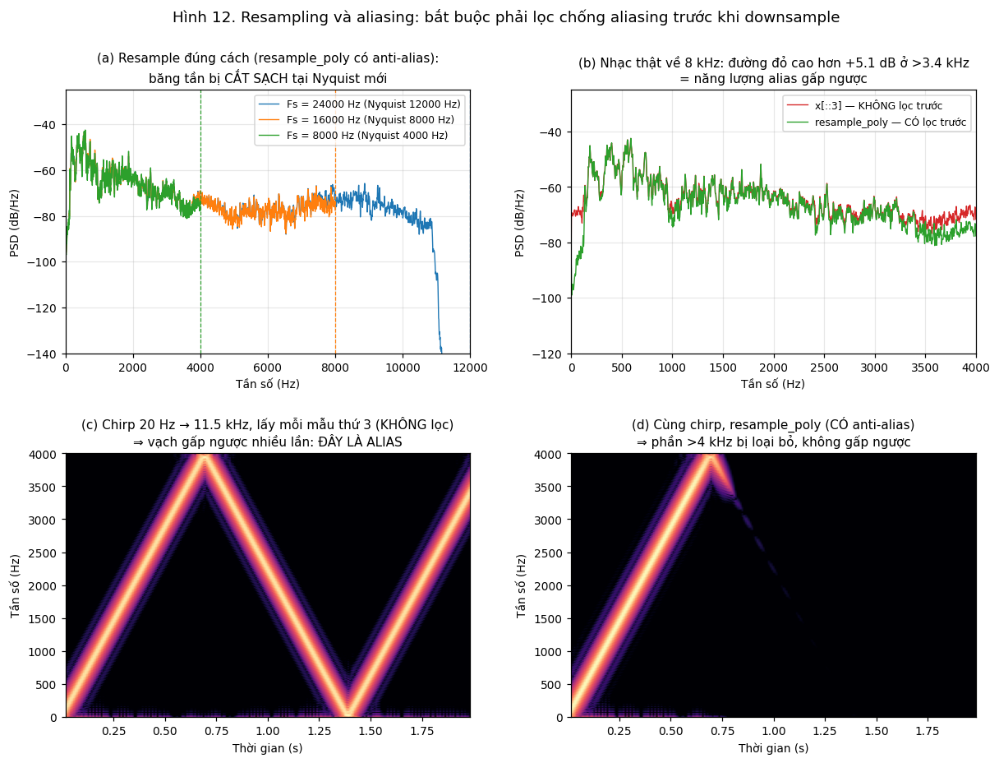

Nghe thử chirp: (1) gốc 24 kHz  (2) 8 kHz KHÔNG lọc — nghe rõ tiếng quét đi xuống  (3) 8 kHz có lọc


In [21]:
fig = plt.figure(figsize=(13, 9))
gs  = fig.add_gridspec(2, 2, hspace=.38, wspace=.25)

a = fig.add_subplot(gs[0,0])
for fs2, c in zip(TARGETS, ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    y = x if fs2 == Fs else signal.resample_poly(x, fs2//np.gcd(fs2,Fs), Fs//np.gcd(fs2,Fs))
    f_, P_ = signal.welch(y, fs2, nperseg=4096)
    a.plot(f_, 10*np.log10(P_+1e-20), lw=.9, color=c, label=f"Fs = {fs2} Hz (Nyquist {fs2//2} Hz)")
    a.axvline(fs2/2, color=c, ls="--", lw=.8)
a.set_xlim(0, Fs/2); a.set_ylim(-140, -25); a.legend(fontsize=8)
a.set_xlabel("Tần số (Hz)"); a.set_ylabel("PSD (dB/Hz)")
a.set_title("(a) Resample đúng cách (resample_poly có anti-alias):\nbăng tần bị CẮT SẠCH tại Nyquist mới", fontsize=10)

a = fig.add_subplot(gs[0,1])
f1_, P1_ = signal.welch(x_naive, 8000, nperseg=4096)
f2_, P2_ = signal.welch(x_ok,    8000, nperseg=4096)
a.plot(f1_, 10*np.log10(P1_+1e-20), lw=.9, color="#d62728", label="x[::3] — KHÔNG lọc trước")
a.plot(f2_, 10*np.log10(P2_+1e-20), lw=.9, color="#2ca02c", label="resample_poly — CÓ lọc trước")
d_hi = float(10*np.log10(P1_[f1_>3400].mean()) - 10*np.log10(P2_[f2_>3400].mean()))
a.set_xlim(0, 4000); a.set_ylim(-120, -25); a.legend(fontsize=8)
a.set_xlabel("Tần số (Hz)"); a.set_ylabel("PSD (dB/Hz)")
a.set_title(f"(b) Nhạc thật về 8 kHz: đường đỏ cao hơn {d_hi:+.1f} dB ở >3.4 kHz\n= năng lượng alias gấp ngược", fontsize=10)

for j, (sig_, lab_) in enumerate([
        (ch_naive, "(c) Chirp 20 Hz → 11.5 kHz, lấy mỗi mẫu thứ 3 (KHÔNG lọc)\n⇒ vạch gấp ngược nhiều lần: ĐÂY LÀ ALIAS"),
        (ch_ok,    "(d) Cùng chirp, resample_poly (CÓ anti-alias)\n⇒ phần >4 kHz bị loại bỏ, không gấp ngược")]):
    a = fig.add_subplot(gs[1,j])
    ff_, tt_, Sc = signal.spectrogram(sig_, 8000, nperseg=256, noverlap=192, nfft=1024, mode="magnitude")
    D = 20*np.log10(Sc + 1e-10)
    a.pcolormesh(tt_, ff_, D, shading="gouraud", cmap="magma", vmin=D.max()-70, vmax=D.max())
    a.set_xlabel("Thời gian (s)"); a.set_ylabel("Tần số (Hz)"); a.set_title(lab_, fontsize=10); a.grid(False)

fig.suptitle("Hình 12. Resampling và aliasing: bắt buộc phải lọc chống aliasing trước khi downsample", fontsize=12)
fig.savefig(f"{FIG}/12_resampling.png"); plt.show()
RESULTS["aliasing_excess_dB_above_3400Hz"] = d_hi

print("Nghe thử chirp: (1) gốc 24 kHz  (2) 8 kHz KHÔNG lọc — nghe rõ tiếng quét đi xuống  (3) 8 kHz có lọc")
for fn in ["chirp_24k_ref.wav", "chirp_8k_ALIASED_naive.wav", "chirp_8k_antialiased.wav"]:
    d_, sr_ = sf.read(f"{AUD}/{fn}"); display(Audio(d_, rate=sr_))

**Nhận xét G.2.**
1. Hình (c) là bằng chứng **không thể nhầm lẫn**: chirp quét lên thẳng, nhưng sau khi bỏ mẫu thủ công nó
   "gấp ngược" tại 4 kHz rồi lại đi xuống. Nghe cũng rõ — tiếng quét lên biến thành tiếng quét xuống.
   Hình (d) dùng `resample_poly`: phần trên 4 kHz bị lọc bỏ hẳn, đường chirp tắt dần chứ không gấp lại.
2. Trên nhạc thật, alias kín đáo hơn vì năng lượng cao tần vốn đã yếu (bị MP3 cắt), nhưng vẫn đo được
   mức nền dải trên 3.4 kHz cao hơn khoảng 5 dB — đó là năng lượng từ dải 4.6–8 kHz gấp xuống.
3. Chất lượng nghe: bản 16 kHz gần như không phân biệt được với bản gốc (vì băng thông hữu ích chủ yếu dưới 8 kHz);
   bản 8 kHz mất hẳn độ sáng, nghe "đục" — giống chất lượng điện thoại, vì mọi thứ trên 4 kHz đã biến mất.

### G.3 Mã hóa: PCM, MP3 và compression ratio

In [22]:
R_pcm_stereo = Fs*16*2
R_pcm_mono   = Fs*16*1
print(f"R_PCM (stereo 16-bit) = Fs × B × C = {Fs:,} × 16 × 2 = {R_pcm_stereo:,} bit/s = {R_pcm_stereo/1000:.1f} kbps")
print(f"R_PCM (mono   16-bit) = {R_pcm_mono:,} bit/s = {R_pcm_mono/1000:.1f} kbps")
print(f"Size ≈ R × Duration / 8 = {R_pcm_stereo*dur/8/1e6:.3f} MB cho {dur:.3f} s")

sf.write(f"{AUD}/pcm16_stereo_24k.wav", stereo.astype(np.float32), Fs, subtype="PCM_16")
print(f"Kích thước WAV thực tế  : {os.path.getsize(f'{AUD}/pcm16_stereo_24k.wav'):,} byte "
      f"(chênh lệch nhỏ do header WAV)")

coding = [dict(fmt="PCM 16-bit stereo 24 kHz (WAV)", byte=int(R_pcm_stereo*dur/8),
               kbps=R_pcm_stereo/1000, ratio=1.0, saving=0.0)]
coding.append(dict(fmt="MP3 gốc (tệp đầu vào)", byte=fsize, kbps=fsize*8/dur/1000,
                   ratio=R_pcm_stereo/(fsize*8/dur), saving=100*(1-fsize/(R_pcm_stereo*dur/8))))
for br in [192, 128, 64, 32]:
    out = f"{AUD}/music_mp3_{br}k.mp3"
    subprocess.run(["ffmpeg","-y","-loglevel","error","-i",f"{AUD}/pcm16_stereo_24k.wav",
                    "-c:a","libmp3lame","-b:a",f"{br}k", out], check=True)
    bts = os.path.getsize(out)
    coding.append(dict(fmt=f"MP3 yêu cầu {br} kbps", byte=bts, kbps=bts*8/dur/1000,
                       ratio=R_pcm_stereo/(bts*8/dur), saving=100*(1-bts/(R_pcm_stereo*dur/8))))

import pandas as pd
dfc = pd.DataFrame(coding)
display(dfc.style.format({"byte":"{:,.0f}", "kbps":"{:.1f}", "ratio":"{:.2f}", "saving":"{:.2f}%"}))
RESULTS["coding"] = coding

R_PCM (stereo 16-bit) = Fs × B × C = 24,000 × 16 × 2 = 768,000 bit/s = 768.0 kbps
R_PCM (mono   16-bit) = 384,000 bit/s = 384.0 kbps
Size ≈ R × Duration / 8 = 1.479 MB cho 15.408 s
Kích thước WAV thực tế  : 1,479,212 byte (chênh lệch nhỏ do header WAV)


,fmt,byte,kbps,ratio,saving
0,PCM 16-bit stereo 24 kHz (WAV),"1,479,168",768.0,1.00,0.00%
1,MP3 gốc (tệp đầu vào),"308,160",160.0,4.80,79.17%
2,MP3 yêu cầu 192 kbps,"309,645",160.8,4.78,79.07%
3,MP3 yêu cầu 128 kbps,"247,725",128.6,5.97,83.25%
4,MP3 yêu cầu 64 kbps,"123,885",64.3,11.94,91.62%
5,MP3 yêu cầu 32 kbps,"62,061",32.2,23.83,95.80%


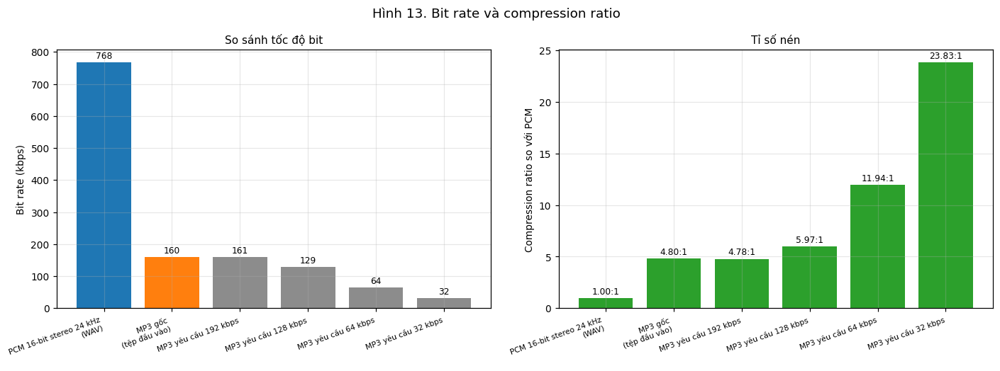

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
names = [c["fmt"].replace(" (", "\n(") for c in dfc.to_dict("records")]
cols  = ["#1f77b4", "#ff7f0e"] + ["#8c8c8c"]*4
ax[0].bar(range(len(dfc)), dfc.kbps, color=cols)
for i, v in enumerate(dfc.kbps):
    ax[0].text(i, v+12, f"{v:.0f}", ha="center", fontsize=8)
ax[0].set_ylabel("Bit rate (kbps)"); ax[0].set_title("So sánh tốc độ bit", fontsize=10)
ax[1].bar(range(len(dfc)), dfc.ratio, color="#2ca02c")
for i, v in enumerate(dfc.ratio):
    ax[1].text(i, v+0.4, f"{v:.2f}:1", ha="center", fontsize=8)
ax[1].set_ylabel("Compression ratio so với PCM"); ax[1].set_title("Tỉ số nén", fontsize=10)
for a in ax:
    a.set_xticks(range(len(dfc))); a.set_xticklabels(names, fontsize=7, rotation=20, ha="right")
fig.suptitle("Hình 13. Bit rate và compression ratio", fontsize=12)
fig.tight_layout(); fig.savefig(f"{FIG}/13_bitrate_compression.png"); plt.show()

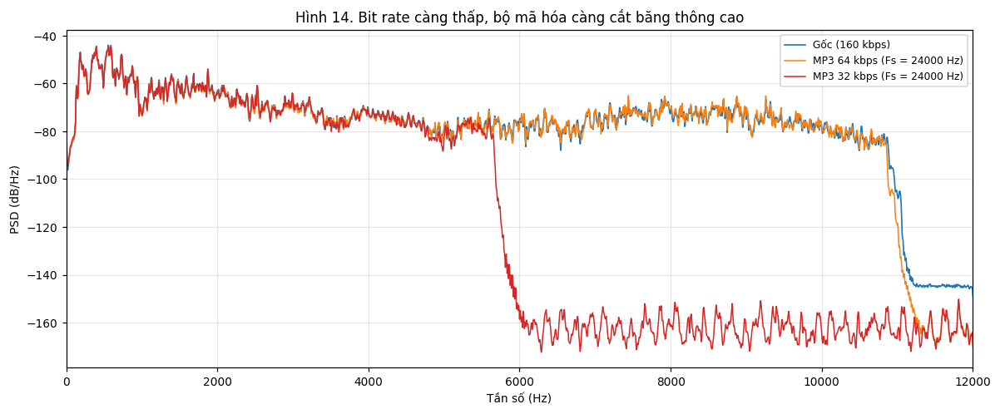

Nghe thử chất lượng theo bit rate: gốc → 128 → 64 → 32 kbps


In [24]:
fig, ax = plt.subplots(figsize=(11, 4.6))
f_, P_ = signal.welch(x, Fs, nperseg=4096)
ax.plot(f_, 10*np.log10(P_+1e-20), lw=1.1, color="#1f77b4", label=f"Gốc ({fsize*8/dur/1000:.0f} kbps)")
for br, c in zip([64, 32], ["#ff7f0e", "#d62728"]):
    d_, sr_ = sf.read(f"{AUD}/music_mp3_{br}k.mp3")
    d_ = d_.mean(axis=1) if d_.ndim > 1 else d_
    f2_, P2_ = signal.welch(d_, sr_, nperseg=4096)
    ax.plot(f2_, 10*np.log10(P2_+1e-20), lw=1, color=c, label=f"MP3 {br} kbps (Fs = {sr_} Hz)")
ax.set_xlim(0, Fs/2); ax.set_xlabel("Tần số (Hz)"); ax.set_ylabel("PSD (dB/Hz)")
ax.set_title("Hình 14. Bit rate càng thấp, bộ mã hóa càng cắt băng thông cao", fontsize=11)
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(f"{FIG}/14_mp3_bandwidth.png"); plt.show()

print("Nghe thử chất lượng theo bit rate: gốc → 128 → 64 → 32 kbps")
display(Audio(x, rate=Fs))
for br in [128, 64, 32]:
    d_, sr_ = sf.read(f"{AUD}/music_mp3_{br}k.mp3"); display(Audio(d_.T, rate=sr_))

**Nhận xét G.3.**
1. PCM 16-bit stereo ở 24 kHz tốn 768 kbps; tệp MP3 gốc chỉ 160 kbps ⇒ **compression ratio ≈ 4.8 : 1**,
   tiết kiệm khoảng 79% dung lượng.
2. Khi yêu cầu 192 kbps, LAME vẫn cho ra ≈ 161 kbps. Không phải lỗi: ở $F_s = 24$ kHz, MP3 chạy ở chế độ
   **MPEG-2 LSF (Low Sampling Frequency)**, mà chuẩn này giới hạn bit rate tối đa 160 kbps. Đây là ví dụ cho thấy
   phải luôn **đo bit rate thực tế** thay vì tin vào tham số đã yêu cầu.
3. Hình 14 cho thấy chiến lược của bộ mã hóa perceptual: khi bit rate giảm, việc đầu tiên nó làm là **hi sinh băng
   thông cao** (32 kbps thậm chí tự đổi sang $F_s = 16$ kHz) vì tai người ít nhạy ở đó — thay vì rải đều
   sai số ra toàn băng như PCM.
4. So sánh quan trọng: **PCM 8-bit** (384 kbps mono, SNR ≈ 32 dB) tốn nhiều bit hơn **MP3 64 kbps** rất nhiều
   nhưng nghe tệ hơn hẳn. Vì MP3 giấu sai số vào những vùng bị masking, còn PCM rải nhiễu đều trên toàn băng.
   Đây là lý do SNR **không** phải thước đo chất lượng nghe.
5. Lưu ý phương pháp luận: tệp gốc đã là MP3 (lossy), nên bản WAV giải mã ra **không phải ground truth không mất mát**.
   Mọi phép nén lại ở đây là nén lần hai (transcoding) và chỉ dùng để so sánh tương đối.

---
## H. Bảng tổng hợp kết quả

In [25]:
import pandas as pd
m = RESULTS["metadata"]
summary = [
    ("Fs / Nyquist",            f"{m['Fs']:,} Hz / {m['nyquist']:,.0f} Hz"),
    ("Kênh, bit sau giải mã",   f"{m['channels']} (stereo), {m['bits']} bit/mẫu"),
    ("Thời lượng, số mẫu",      f"{m['duration']:.3f} s, {m['n_samples']:,} mẫu/kênh"),
    ("Kích thước tệp MP3",      f"{m['file_bytes']:,} byte ({m['mp3_kbps']:.0f} kbps)"),
    ("Peak / RMS (mono)",       f"{dbfs(sM['peak']):.2f} dBFS / {dbfs(sM['rms']):.2f} dBFS"),
    ("Crest factor",            f"{dbfs(sM['peak'])-dbfs(sM['rms']):.2f} dB"),
    ("Clipping",                "không (0 mẫu chạm full-scale)"),
    ("Đoạn phân tích FFT",      f"{T0:.2f}–{T0+SEG_DUR:.2f} s"),
    ("Δf @ NFFT 2048/32768",    f"{Fs/2048:.2f} Hz / {Fs/32768:.3f} Hz"),
    ("Độ phân giải THỰC (L=1 s)", f"≈ {2*Fs/Lseg:.2f} Hz"),
    ("f0 và hoạ âm",            f"{RESULTS['fft']['f0']:.0f}, " +
                                ", ".join(f"{p:.0f}" for p,_ in RESULTS['fft']['peaks'][1:4]) + " Hz"),
    ("Băng thông hiệu dụng",    f"≈ {RESULTS['bandwidth_Hz']:,.0f} Hz (< Nyquist ⇒ dấu vết MP3)"),
    ("STFT chuẩn",              f"L = {Lw} mẫu (25 ms), H = {Hp} mẫu (10 ms), overlap 60%"),
    ("Δf_true 10/25/50 ms",     f"{2*Fs/round(0.010*Fs):.0f} / {2*Fs/Lw:.0f} / {2*Fs/round(0.050*Fs):.0f} Hz"),
    ("Cửa sổ: main-lobe",       f"rect {ml_r:.0f} Hz vs Hamming {ml_h:.0f} Hz"),
    ("Cửa sổ: side-lobe",       f"rect {sl_r:.1f} dB vs Hamming {sl_h:.1f} dB"),
    ("FIR 201 taps",            f"group delay {gd} mẫu = {1000*gd/Fs:.2f} ms"),
    ("SNR lượng tử 4/8/16 bit", " / ".join(f"{r['SNR_do']:.1f}" for r in rows if r['B'] in (4,8,16)) + " dB"),
    ("Độ dốc SNR (B ≥ 4)",      f"{slope_4_16:.2f} dB/bit (lý thuyết 6.02)"),
    ("20log10(Xmax/σx)",        f"{headroom:.2f} dB"),
    ("R_PCM stereo",            f"{R_pcm_stereo/1000:.1f} kbps ⇒ {R_pcm_stereo*dur/8/1e6:.3f} MB"),
    ("Compression ratio MP3 gốc", f"{R_pcm_stereo/(fsize*8/dur):.2f} : 1 (tiết kiệm "
                                  f"{100*(1-fsize/(R_pcm_stereo*dur/8)):.1f}%)"),
]
display(pd.DataFrame(summary, columns=["Đại lượng", "Giá trị đo được"]).style.hide(axis="index"))

with open("results_summary.json", "w", encoding="utf-8") as fp:
    json.dump(RESULTS, fp, ensure_ascii=False, indent=2, default=float)
print("\nĐã ghi results_summary.json")
print("Hình đã sinh :", len([n for n in sorted(os.listdir(FIG)) if n.endswith('.png')]), "tệp trong figures/")
print("Audio đã sinh:", len(os.listdir(AUD)), "tệp trong audio/")

Đại lượng,Giá trị đo được
Fs / Nyquist,"24,000 Hz / 12,000 Hz"
"Kênh, bit sau giải mã","2 (stereo), 16 bit/mẫu"
"Thời lượng, số mẫu","15.408 s, 369,792 mẫu/kênh"
Kích thước tệp MP3,"308,160 byte (160 kbps)"
Peak / RMS (mono),-1.23 dBFS / -21.58 dBFS
Crest factor,20.34 dB
Clipping,không (0 mẫu chạm full-scale)
Đoạn phân tích FFT,1.62–2.62 s
Δf @ NFFT 2048/32768,11.72 Hz / 0.732 Hz
Độ phân giải THỰC (L=1 s),≈ 2.00 Hz



Đã ghi results_summary.json
Hình đã sinh : 14 tệp trong figures/
Audio đã sinh: 19 tệp trong audio/


---
## Danh mục tệp âm thanh xuất ra

| Tệp | Cấu hình |
|---|---|
| `mono_norm.wav` | mono, 24 kHz, chuẩn hóa [−1,1] |
| `music_lpf_2k.wav` | FIR low-pass 2 kHz, 201 taps, đã bù group delay |
| `music_hpf_3k.wav` | FIR high-pass 3 kHz, 201 taps |
| `music_bpf_300_3400.wav` | FIR band-pass 300–3400 Hz |
| `music_4bit.wav`, `music_8bit.wav`, `music_16bit.wav` | lượng tử đều B bit |
| `music_16k.wav`, `music_8k.wav` | resample đúng cách (có anti-alias) |
| `music_8k_ALIASED_naive.wav` | bỏ mẫu thủ công — **có alias**, dùng để đối chứng |
| `chirp_24k_ref.wav`, `chirp_8k_ALIASED_naive.wav`, `chirp_8k_antialiased.wav` | chirp kiểm chứng aliasing |
| `pcm16_stereo_24k.wav` | PCM không nén để tính compression ratio |
| `music_mp3_{192,128,64,32}k.mp3` | các mức nén để so sánh |

Phần trả lời 7 câu hỏi báo cáo nằm trong `report_Lab01.md`.